In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     learning_curve, KFold)
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              classification_report, confusion_matrix)

In [2]:
# ── 1. Load dataset ───────────────────────────────
cancer = load_breast_cancer()
X, y   = cancer.data, cancer.target
feature_names = cancer.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


── Overfitting Demo ──


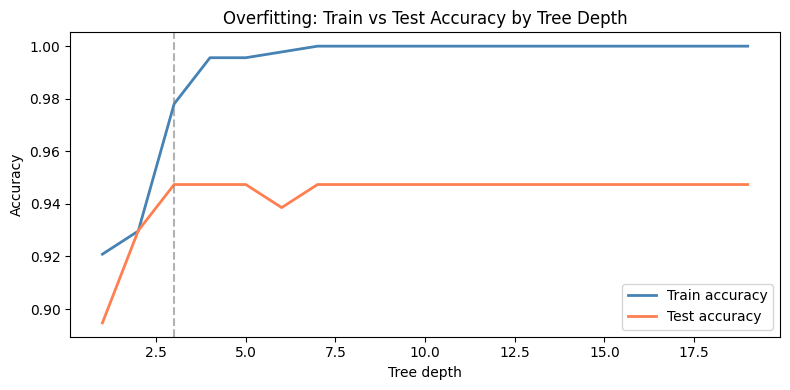

Best depth: 3


In [3]:
# ── 2. Demonstrate overfitting ────────────────────
print("── Overfitting Demo ──")
depths   = range(1, 20)
train_scores, test_scores = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))

plt.figure(figsize=(8, 4))
plt.plot(depths, train_scores, label='Train accuracy', color='steelblue', lw=2)
plt.plot(depths, test_scores,  label='Test accuracy',  color='coral',     lw=2)
plt.axvline(x=np.argmax(test_scores)+1, color='gray', linestyle='--', alpha=0.6)
plt.xlabel('Tree depth')
plt.ylabel('Accuracy')
plt.title('Overfitting: Train vs Test Accuracy by Tree Depth')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Best depth: {np.argmax(test_scores)+1}")


In [4]:
# ── 3. Evaluation metrics ─────────────────────────
print("\n── Evaluation Metrics ──")
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\n", classification_report(y_test, y_pred,
      target_names=cancer.target_names))



── Evaluation Metrics ──
Accuracy : 0.9737
Precision: 0.9722
Recall   : 0.9859
F1 Score : 0.9790
ROC-AUC  : 0.9974

               precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



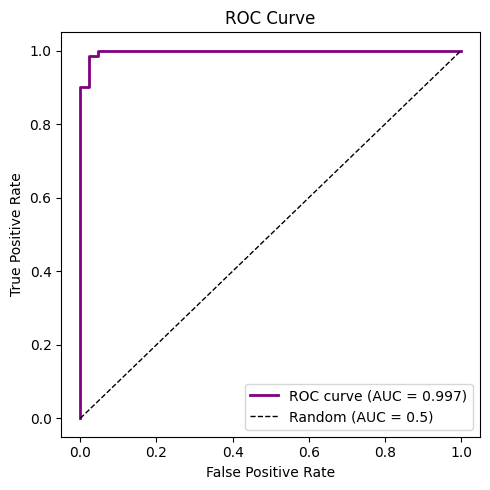

In [5]:
# ── 4. ROC Curve ──────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='purple', lw=2,
         label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()


── 5-Fold Cross-Validation ──
Scores per fold: [0.9825 0.9825 0.9737 0.9737 0.9912]
Mean accuracy  : 0.9807
Std deviation  : 0.0065


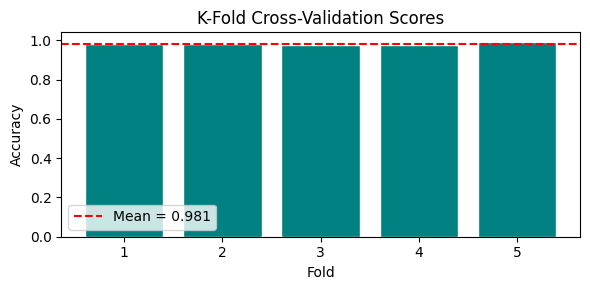

In [6]:
# ── 5. K-Fold cross-validation ────────────────────
print("\n── 5-Fold Cross-Validation ──")
X_scaled = scaler.fit_transform(X)
cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000), X_scaled, y, cv=5, scoring='accuracy')

print(f"Scores per fold: {cv_scores.round(4)}")
print(f"Mean accuracy  : {cv_scores.mean():.4f}")
print(f"Std deviation  : {cv_scores.std():.4f}")

plt.figure(figsize=(6, 3))
plt.bar(range(1, 6), cv_scores, color='teal', edgecolor='white')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', lw=1.5,
            label=f'Mean = {cv_scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('K-Fold Cross-Validation Scores')
plt.legend()
plt.tight_layout()
plt.show()


── Regularization Effect ──


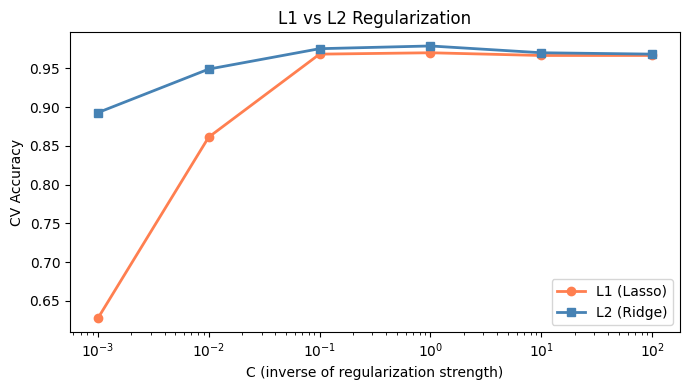

In [9]:
# ── 6. Regularization: L1 vs L2 ──────────────────
import warnings
warnings.filterwarnings('ignore')

print("\n── Regularization Effect ──")
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
l1_scores, l2_scores = [], []

for C in C_values:
    l1 = LogisticRegression(l1_ratio=1, C=C, solver='saga', max_iter=2000)
    l2 = LogisticRegression(l1_ratio=0, C=C, solver='saga', max_iter=2000)
    l1_scores.append(cross_val_score(l1, X_scaled, y, cv=5).mean())
    l2_scores.append(cross_val_score(l2, X_scaled, y, cv=5).mean())

plt.figure(figsize=(7, 4))
plt.semilogx(C_values, l1_scores, 'o-', label='L1 (Lasso)', color='coral',     lw=2)
plt.semilogx(C_values, l2_scores, 's-', label='L2 (Ridge)', color='steelblue', lw=2)
plt.xlabel('C (inverse of regularization strength)')
plt.ylabel('CV Accuracy')
plt.title('L1 vs L2 Regularization')
plt.legend()
plt.tight_layout()
plt.show()

warnings.filterwarnings('default')  # reset after the cell